# Weyl reverse geometry with the third coefficient $A_2$

This notebook validates computed Dirichlet eigenvalues on the triaxial ellipsoid
$\Omega(1,1.5,2.3)$ by fitting the three-term Weyl law $N(\lambda)=A_0\lambda^{3/2}+A_1\lambda+A_2\lambda^{1/2}+o(\lambda^{1/2})$. The induced geometric estimates are $V=6\pi^2A_0$ and $S=-16\pi A_1$ and $C=6\pi^2A_2$, where $C=\int_{\partial\Omega}\bar H\,dS$ is the integrated mean curvature with $\bar H=(\kappa_1+\kappa_2)/2$. The key point is the factor 6, not 12, in $C=6\pi^2A_2$.

In [1]:
import sys
sys.path.insert(0, "/home/esul01/hearing-ellipsoid-bench/src")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hearing_ellipsoid_bench.io.eigenvalues import load_eigenvalues_txt
from hearing_ellipsoid_bench.geometry.ellipsoid import (
    true_ellipsoid_volume,
    ellipsoid_surface_area,
    ellipsoid_integrated_mean_curvature,
)

In [2]:
PROJECT_ROOT = Path.home() / "hearing-ellipsoid-bench"
DATA_ROOT = Path.home() / "data"
REFERENCE_DIR = DATA_ROOT / "reference"
GENERATED_DIR = DATA_ROOT / "generated"
OUTPUTS_DIR = DATA_ROOT / "outputs"
ARNOLDI_DIR = OUTPUTS_DIR / "arnoldi_reference_triaxial"
SLEPC_DIR = OUTPUTS_DIR / "slepc_slicing_triaxial"
SLEPC64_DIR = OUTPUTS_DIR / "slepc_slicing_triaxial_h003_i64"
SSG_DIR = OUTPUTS_DIR / "ssg_reference_triaxial"
MFS_DIR = OUTPUTS_DIR / "boundary_mfs_triaxial_windows"
HANKEL_DIR = OUTPUTS_DIR / "hankel_full_spectrum_triaxial"

OUT_DIR = OUTPUTS_DIR / "reverse_geometry_a2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Fixed geometry and reference values

These values are computed from the prescribed semi-axes before any eigenvalue computation enters.

In [3]:
a, b, c = 1.0, 1.5, 2.3

# Which eigenvalue files should be compared?
EIG_FILES = {
    "arnoldi_P2_h0.06_N2000": ARNOLDI_DIR / "ellipsoid_a1_b1.5_c2.3_P2_h0.06_arnoldi_highacc_N2000_eigs.txt",
    "slepc_h0.06_N2050":      SLEPC_DIR / "a1_b1.5_c2.3_P2_h0.06_top449.118296481_slepc_slicing_eigs.txt",
    "ssg_l22_n20_N2000":      SSG_DIR / "ellipsoid_a1_b1.5_c2.3_l36_n20_qr64_qt56_qp112_ssg_N2000_eigs.txt",
    "hankel_certified":       HANKEL_DIR / "full_spectrum_eigs_certified.txt",
    "slepc_h0.03_N2050":      SLEPC64_DIR / "a1_b1.5_c2.3_P2_h0.03_top449.118296481_slepc_slicing_n32p2_eigs.txt",
}

# Fit window configuration.
# Each plotted point K uses eigenvalues from FIT_START to K.
FIT_START = 30       # try 1, 50, 100, 200
FIT_END_MAX = 1600  # None = use all available eigenvalues per method

K_VALUES_BASE = np.array([
    50, 100, 150, 200, 300, 400, 500, 600, 700, 800,
    1000, 1200, 1500, 2000, 2500, 3000, 4000, 5000
])

# Plot Configuration
K_MAX_PLOT = None  # None = full range
Y_LIMITS = {
    "V_est_3term": (13, 16), # None = full range
    "S_est_3term": (10, 50), # None = full range
    "C_est_3term": (-50, 50), # None = full range
    "V_rel_err_3term": (-0.2, 0.2), # None = full range
    "S_rel_err_3term": (-1, 1), # None = full range
    "C_rel_err_3term": (-15, 15) # None = full range
}

# Mapping von Dateinamen (Keys in EIG_FILES) zu den Anzeigennamen
NAME_MAPPING = {
    "arnoldi_P2_h0.06_N2000": "FEM--ARPACK",
    "slepc_h0.06_N2050" : "SLEPc 0.06",
    "ssg_l22_n20_N2000": "SSG",
    "hankel_certified": "block-Hankel",
    "slepc_h0.03_N2050": "SLEPc 0.03",
}

STYLES = {
    "FEM--ARPACK":  dict(color="#1f77b4", linestyle="-", linewidth=8.0, alpha=0.25, zorder=1, solid_capstyle="round"),
    "block-Hankel": dict(color="#d62728", linestyle="-", linewidth=3.4, alpha=0.55, zorder=2, solid_capstyle="round"),
    "SSG":          dict(color="#2ca02c", linestyle="-", linewidth=1.8, zorder=3, solid_capstyle="round"),
    "SLEPc 0.06":   dict(color="#111111", linestyle=(0, (5, 3)), linewidth=1, zorder=4),
    "SLEPc 0.03":   dict(color="#ff0000", linestyle="-", linewidth=1, alpha=1, zorder=2, solid_capstyle="round"),
}

PLOT_ORDER = ["FEM--ARPACK", "block-Hankel", "SSG", "SLEPc 0.06", "SLEPc 0.03"]

In [4]:
V_true = true_ellipsoid_volume(a, b, c)
S_true = ellipsoid_surface_area(a, b, c)
C_true = ellipsoid_integrated_mean_curvature(a, b, c, n_theta=240, n_phi=480)

A0_true = V_true / (6 * np.pi**2)
A1_true = -S_true / (16 * np.pi)
A2_true = C_true / (6 * np.pi**2)

ref = pd.DataFrame([
    {"quantity": "volume", "reference": V_true, "Weyl coefficient": A0_true},
    {"quantity": "surface area", "reference": S_true, "Weyl coefficient": A1_true},
    {"quantity": "integrated mean curvature", "reference": C_true, "Weyl coefficient": A2_true},
])

ref

,quantity,reference,Weyl coefficient
0,volume,14.451326,0.244038
1,surface area,31.355382,-0.623796
2,integrated mean curvature,20.769300,0.350728


# Loading / Plotting Part

## 2. Load eigenvalues

In [5]:
eigs_by_method = {}

for name, path in EIG_FILES.items():
    path = Path(path)

    if not path.exists():
        print(f"missing: {name} -> {path}")
        continue

    # Verwendet das Mapping, falls vorhanden; sonst Fallback auf 'name'
    method_key = NAME_MAPPING.get(name, name)

    eigs = load_eigenvalues_txt(path)
    eigs = np.asarray(eigs, dtype=float)
    eigs = eigs[np.isfinite(eigs)]
    eigs = eigs[eigs > 0]
    eigs = np.sort(eigs)

    eigs_by_method[method_key] = eigs
    
    print(f"{name:28s}: {len(eigs):6d} eigenvalues from {path}")

if not eigs_by_method:
    raise FileNotFoundError("No eigenvalue files found. Check EIG_FILES.")

# Fair comparison: truncate all methods at the same spectral cutoff,
# not at the same index count (the certified Hankel spectrum contains
# 34 additional true levels that shift indices otherwise).
lam_cut = min(v.max() for v in eigs_by_method.values())
for name in list(eigs_by_method):
    v = eigs_by_method[name]
    eigs_by_method[name] = v[v <= lam_cut * (1 + 1e-12)]
    print(f"{name:28s}: {len(eigs_by_method[name]):6d} eigenvalues <= {lam_cut:.4f}")

arnoldi_P2_h0.06_N2000      :   2000 eigenvalues from /home/esul01/data/outputs/arnoldi_reference_triaxial/ellipsoid_a1_b1.5_c2.3_P2_h0.06_arnoldi_highacc_N2000_eigs.txt
slepc_h0.06_N2050           :   2034 eigenvalues from /home/esul01/data/outputs/slepc_slicing_triaxial/a1_b1.5_c2.3_P2_h0.06_top449.118296481_slepc_slicing_eigs.txt
ssg_l22_n20_N2000           :   2000 eigenvalues from /home/esul01/data/outputs/ssg_reference_triaxial/ellipsoid_a1_b1.5_c2.3_l36_n20_qr64_qt56_qp112_ssg_N2000_eigs.txt
hankel_certified            :   2034 eigenvalues from /home/esul01/data/outputs/hankel_full_spectrum_triaxial/full_spectrum_eigs_certified.txt
slepc_h0.03_N2050           :   2050 eigenvalues from /home/esul01/data/outputs/slepc_slicing_triaxial_h003_i64/a1_b1.5_c2.3_P2_h0.03_top449.118296481_slepc_slicing_n32p2_eigs.txt
FEM--ARPACK                 :   1993 eigenvalues <= 443.7525
SLEPc 0.06                  :   1993 eigenvalues <= 443.7525
SSG                         :   2000 eigenvalues <=

## 3. Fit the three-term Weyl law along increasing cutoffs

In [6]:
def fit_weyl_3term_window(eigs, fit_start=1, fit_end=None):
    """
    Fit N(lambda) = A0 lambda^(3/2) + A1 lambda + A2 lambda^(1/2)
    on the eigenvalue index window [fit_start, fit_end].

    fit_start and fit_end are 1-based eigenvalue indices.
    """
    eigs = np.asarray(eigs, dtype=float)
    eigs = eigs[np.isfinite(eigs)]
    eigs = eigs[eigs > 0]
    eigs = np.sort(eigs)

    n_total = len(eigs)

    if fit_end is None:
        fit_end = n_total

    fit_start = int(fit_start)
    fit_end = int(fit_end)

    if fit_start < 1:
        raise ValueError("fit_start must be >= 1.")

    if fit_end > n_total:
        raise ValueError(f"fit_end={fit_end} exceeds available eigenvalues {n_total}.")

    if fit_end - fit_start + 1 < 3:
        raise ValueError("Need at least 3 eigenvalues for a 3-term fit.")

    # 1-based indices: lambda_{fit_start}, ..., lambda_{fit_end}
    lam = eigs[fit_start - 1:fit_end]

    # Crucial: use the true counting-function indices, not 1..window_length.
    counts = np.arange(fit_start, fit_end + 1, dtype=float)

    X = np.column_stack([
        lam ** 1.5,
        lam,
        lam ** 0.5,
    ])

    # Mild column scaling improves numerical conditioning.
    scale = np.linalg.norm(X, axis=0)
    scale[scale == 0] = 1.0

    coef_scaled, *_ = np.linalg.lstsq(X / scale, counts, rcond=None)
    A0, A1, A2 = coef_scaled / scale

    return float(A0), float(A1), float(A2)


def reverse_geometry_window_table(
    eigs_by_method,
    *,
    a,
    b,
    c,
    k_values,
    fit_start=1,
    n_theta=240,
    n_phi=480,
):
    V_ref = true_ellipsoid_volume(a, b, c)
    S_ref = ellipsoid_surface_area(a, b, c)
    C_ref = ellipsoid_integrated_mean_curvature(a, b, c, n_theta=n_theta, n_phi=n_phi)

    rows = []

    for method, eigs in eigs_by_method.items():
        eigs = np.asarray(eigs, dtype=float)
        eigs = eigs[np.isfinite(eigs)]
        eigs = eigs[eigs > 0]
        eigs = np.sort(eigs)

        for K in k_values:
            K = int(K)

            if K > len(eigs):
                continue

            if K < fit_start + 2:
                continue

            A0, A1, A2 = fit_weyl_3term_window(
                eigs,
                fit_start=fit_start,
                fit_end=K,
            )

            V_est = 6 * np.pi**2 * A0
            S_est = -16 * np.pi * A1
            C_est = 6 * np.pi**2 * A2

            rows.append({
                "method": method,
                "fit_start": fit_start,
                "K": K,
                "A0_3term": A0,
                "A1_3term": A1,
                "A2_3term": A2,
                "V_est_3term": V_est,
                "S_est_3term": S_est,
                "C_est_3term": C_est,
                "V_true": V_ref,
                "S_true": S_ref,
                "C_true": C_ref,
                "V_rel_err_3term": (V_est - V_ref) / V_ref,
                "S_rel_err_3term": (S_est - S_ref) / S_ref,
                "C_rel_err_3term": (C_est - C_ref) / C_ref,
            })

    return pd.DataFrame(rows)

## 4. Create Table

In [7]:
max_available = max(len(v) for v in eigs_by_method.values())

log_grid = np.unique(
    np.logspace(np.log10(max(50, FIT_START + 2)), np.log10(max_available), 28).astype(int)
)

base = np.unique(np.r_[K_VALUES_BASE, log_grid])

if FIT_END_MAX is not None:
    base = base[base <= FIT_END_MAX]

k_values = [int(K) for K in base if K >= FIT_START + 2 and K <= max_available]

print("FIT_START:", FIT_START)
print("k_values:", k_values)

rg = reverse_geometry_window_table(
    eigs_by_method,
    a=a,
    b=b,
    c=c,
    k_values=k_values,
    fit_start=FIT_START,
    n_theta=240,
    n_phi=480,
)

rg.tail()

FIT_START: 30
k_values: [49, 50, 57, 65, 75, 86, 99, 100, 113, 130, 149, 150, 171, 196, 200, 225, 258, 296, 300, 339, 389, 400, 446, 500, 511, 586, 600, 672, 700, 771, 800, 884, 1000, 1014, 1162, 1200, 1333, 1500, 1528]


,method,fit_start,K,A0_3term,A1_3term,A2_3term,V_est_3term,S_est_3term,C_est_3term,V_true,S_true,C_true,V_rel_err_3term,S_rel_err_3term,C_rel_err_3term
190,SLEPc 0.03,30,1162,0.243516,-0.617081,0.384431,14.420459,31.017886,22.765098,14.451326,31.355382,20.7693,-0.002136,-0.010764,0.096094
191,SLEPc 0.03,30,1200,0.243829,-0.624797,0.429698,14.438998,31.405712,25.445698,14.451326,31.355382,20.7693,-0.000853,0.001605,0.225159
192,SLEPc 0.03,30,1333,0.243940,-0.627447,0.444816,14.445537,31.538950,26.340956,14.451326,31.355382,20.7693,-0.000401,0.005854,0.268264
193,SLEPc 0.03,30,1500,0.243232,-0.608775,0.327904,14.403594,30.600352,19.417702,14.451326,31.355382,20.7693,-0.003303,-0.024080,-0.065077
194,SLEPc 0.03,30,1528,0.243486,-0.615526,0.370389,14.418675,30.939689,21.933556,14.451326,31.355382,20.7693,-0.002259,-0.013257,0.056057


## Plot

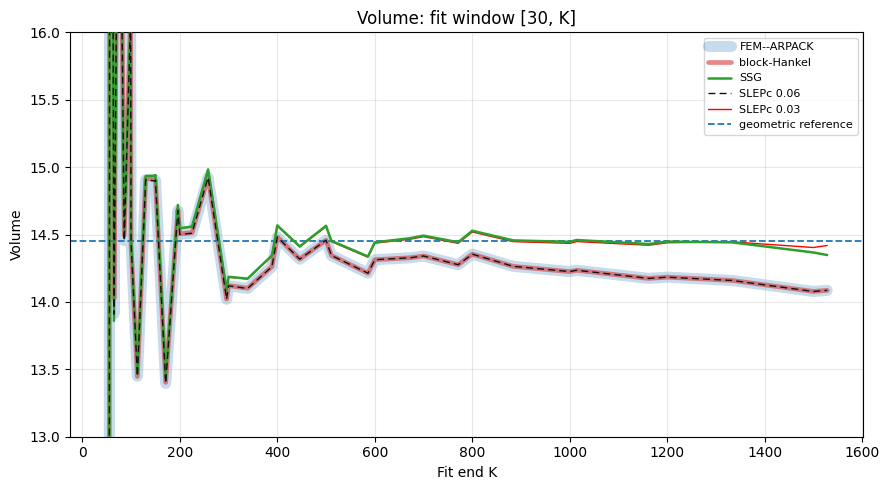

saved: /home/esul01/data/outputs/reverse_geometry_a2/reverse_volume_reference_line.png
saved: /home/esul01/data/outputs/reverse_geometry_a2/reverse_volume_reference_line.pdf


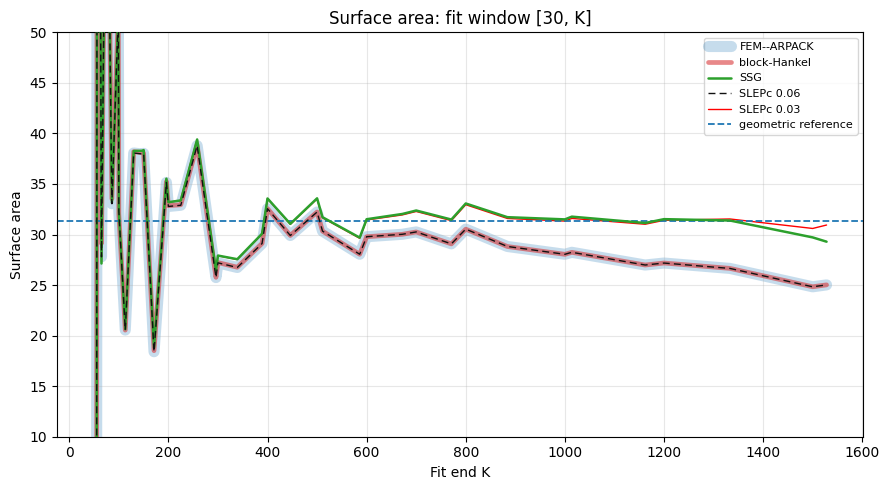

saved: /home/esul01/data/outputs/reverse_geometry_a2/reverse_surface_reference_line.png
saved: /home/esul01/data/outputs/reverse_geometry_a2/reverse_surface_reference_line.pdf


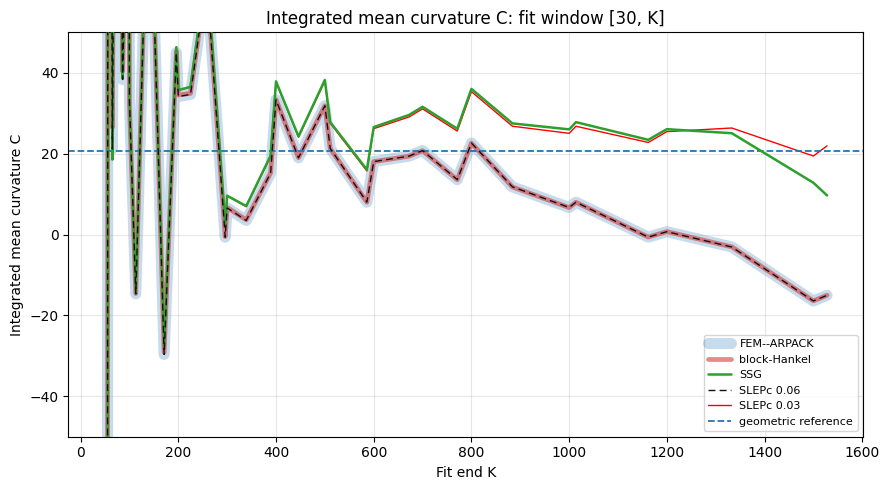

saved: /home/esul01/data/outputs/reverse_geometry_a2/reverse_curvature_reference_line.png
saved: /home/esul01/data/outputs/reverse_geometry_a2/reverse_curvature_reference_line.pdf


In [8]:
df_plot = rg.copy()

if K_MAX_PLOT is not None:
    df_plot = df_plot[df_plot["K"] <= K_MAX_PLOT].copy()

plot_specs = [
    ("V_est_3term", "V_true", "Volume", "reverse_volume_reference_line.png"),
    ("S_est_3term", "S_true", "Surface area", "reverse_surface_reference_line.png"),
    ("C_est_3term", "C_true", "Integrated mean curvature C", "reverse_curvature_reference_line.png"),
]

for estimate_col, ref_col, ylabel, filename in plot_specs:
    fig, ax = plt.subplots(figsize=(9, 5))

    for method in [m for m in PLOT_ORDER if m in set(df_plot["method"])]:
        part = df_plot[df_plot["method"] == method].sort_values("K")
        ax.plot(part["K"], part[estimate_col], label=NAME_MAPPING.get(method, method), **STYLES.get(method, dict(marker="o", linewidth=1.4)))
    
    ref_value = float(df_plot[ref_col].dropna().iloc[0])
    ax.axhline(
        ref_value,
        linestyle="--",
        linewidth=1.3,
        label="geometric reference",
    )

    ax.set_xlabel("Fit end K")
    ax.set_ylabel(ylabel)

    ylim = Y_LIMITS.get(estimate_col)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_title(f"{ylabel}: fit window [{FIT_START}, K]")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    fig.tight_layout()

    png_path = OUT_DIR / filename
    pdf_path = OUT_DIR / Path(filename).with_suffix(".pdf").name

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    plt.show()

    print("saved:", png_path)
    print("saved:", pdf_path)

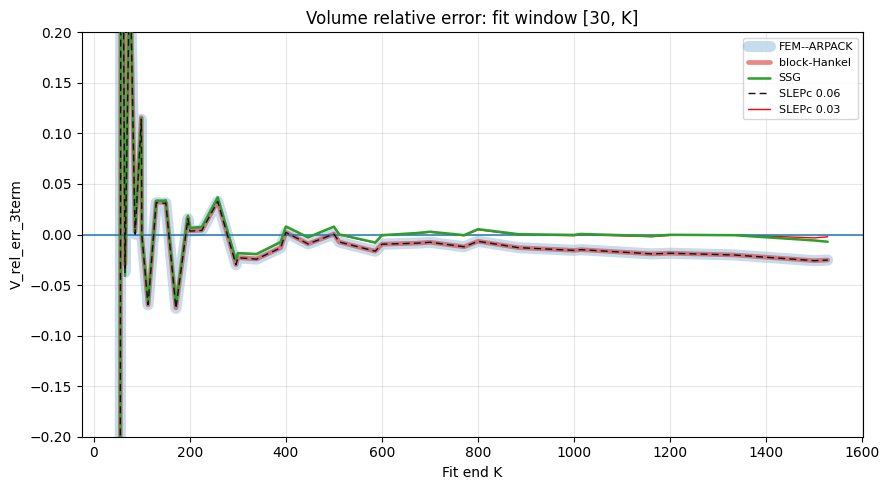

saved: /home/esul01/data/outputs/reverse_geometry_a2/V_rel_err_3term_fitstart_30.png
saved: /home/esul01/data/outputs/reverse_geometry_a2/V_rel_err_3term_fitstart_30.pdf


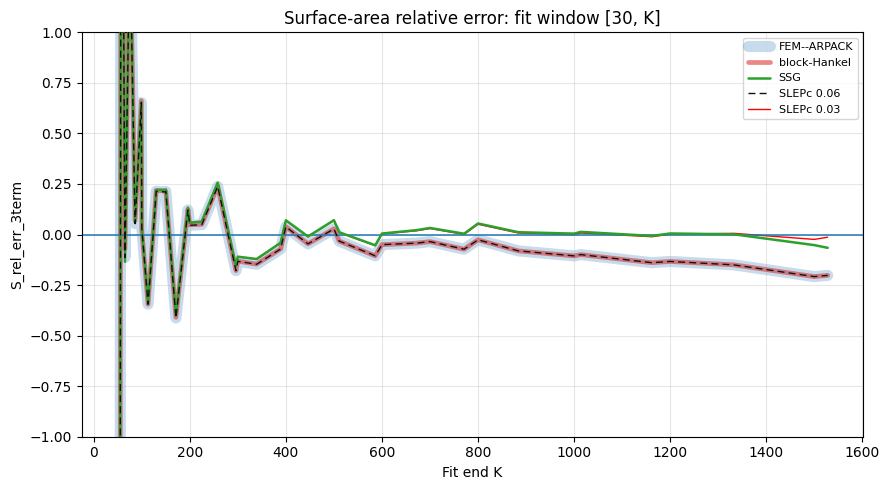

saved: /home/esul01/data/outputs/reverse_geometry_a2/S_rel_err_3term_fitstart_30.png
saved: /home/esul01/data/outputs/reverse_geometry_a2/S_rel_err_3term_fitstart_30.pdf


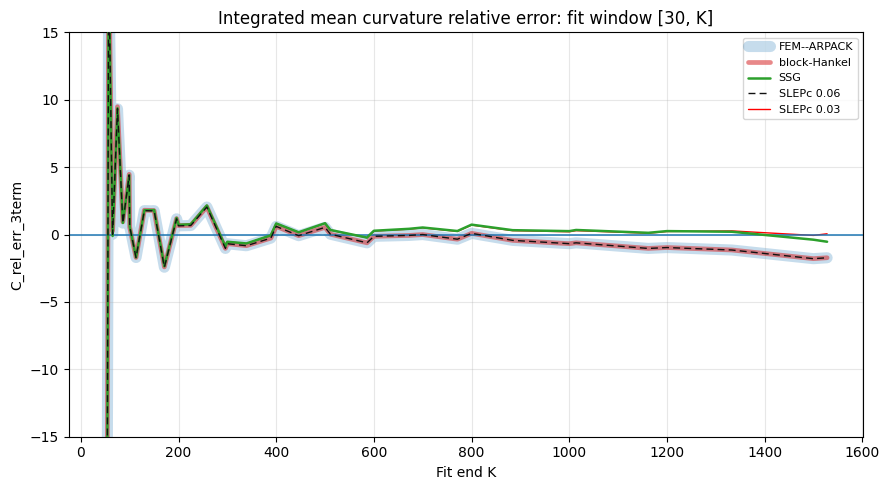

saved: /home/esul01/data/outputs/reverse_geometry_a2/C_rel_err_3term_fitstart_30.png
saved: /home/esul01/data/outputs/reverse_geometry_a2/C_rel_err_3term_fitstart_30.pdf


In [9]:
error_specs = [
    ("V_rel_err_3term", "Volume relative error"),
    ("S_rel_err_3term", "Surface-area relative error"),
    ("C_rel_err_3term", "Integrated mean curvature relative error"),
]

for err_col, title in error_specs:
    fig, ax = plt.subplots(figsize=(9, 5))

    for method in [m for m in PLOT_ORDER if m in set(df_plot["method"])]:
        part = df_plot[df_plot["method"] == method].sort_values("K")
        ax.plot(part["K"], part[err_col], label=NAME_MAPPING.get(method, method), **STYLES.get(method, dict(marker="o", linewidth=1.4)))

    ax.axhline(0.0, linewidth=1.1)
    ax.set_xlabel("Fit end K")
    ax.set_ylabel(err_col)

    ylim = Y_LIMITS.get(err_col)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_title(f"{title}: fit window [{FIT_START}, K]")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()

    png_path = OUT_DIR / f"{err_col}_fitstart_{FIT_START}.png"
    pdf_path = OUT_DIR / f"{err_col}_fitstart_{FIT_START}.pdf"

    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    print("saved:", png_path)
    print("saved:", pdf_path)

In [10]:
K_REF = df_plot["K"].max()
tab = (df_plot[df_plot["K"] == K_REF]
       .set_index("method")[["V_rel_err_3term", "S_rel_err_3term", "C_rel_err_3term"]]
       .abs().mul(100).round(4))
print(f"relative Fehler in % bei K = {K_REF}")
print(tab.to_string())

sub = df_plot[df_plot["K"] >= 0.7 * df_plot["K"].max()]
print(sub.groupby("method")[["V_rel_err_3term","S_rel_err_3term","C_rel_err_3term"]]
        .apply(lambda d: d.abs().median()*100).round(4).to_string())

relative Fehler in % bei K = 1528
              V_rel_err_3term  S_rel_err_3term  C_rel_err_3term
method                                                         
FEM--ARPACK            2.5285          20.2091         172.3647
SLEPc 0.06             2.5285          20.2091         172.3647
SSG                    0.7154           6.5798          53.4900
block-Hankel           2.5279          20.2023         172.2793
SLEPc 0.03             0.2259           1.3257           5.6057
              V_rel_err_3term  S_rel_err_3term  C_rel_err_3term
method                                                         
FEM--ARPACK            2.0213          15.0122         114.8670
SLEPc 0.03             0.2136           1.0764           9.6094
SLEPc 0.06             2.0213          15.0122         114.8670
SSG                    0.1504           0.6871          25.4398
block-Hankel           2.0202          15.0005         114.7285
